In [32]:
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
import pandas as pd
import numpy as np

username = "root"
password = quote_plus("")  # keep this if blank password worked
host = "localhost"
port = 3306
database = "case_study_hmw"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES;"))
    for row in result:
        print(row[0])


airqualityuci
sfcrime2024
sfcrime2025
titanic
titanic_family_size
titanic_with_family_id
titanic_with_family_size
titanic_with_title


-- 3. Is crime overall going down from 2024 -> 2025?

I notice earlier that the best way to answer this question is by counting
how many unique IncidentIDs are in the table. 


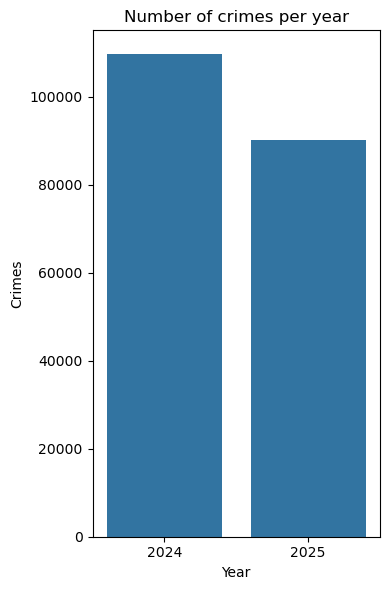

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

query = '''
SELECT 
    IncidentYear,
    COUNT(*) AS num_crimes,
    '2024 data' AS source
FROM sfcrime2024
GROUP BY IncidentYear

UNION ALL

SELECT 
    IncidentYear,
    COUNT(*) AS num_crimes,
    '2025 data' AS source
FROM sfcrime2025
GROUP BY IncidentYear;
'''

df = pd.read_sql(query, engine)

fig, ax = plt.subplots(figsize=(4,6))
sns.barplot(data=df[0:-1], x='IncidentYear', y='num_crimes', ax=ax)

ax.set_title('Number of crimes per year')
ax.set_xlabel('Year')
ax.set_ylabel('Crimes')
plt.tight_layout()
plt.show()

# 4. What breakdowns might be important to investigate? 
Pick at least 3 breakdowns
Think type of crime, think geographic, think resolution, etc... 

## 4(a).
How did the total number of incidents per neighborhood 
change from 2024 to 2025?




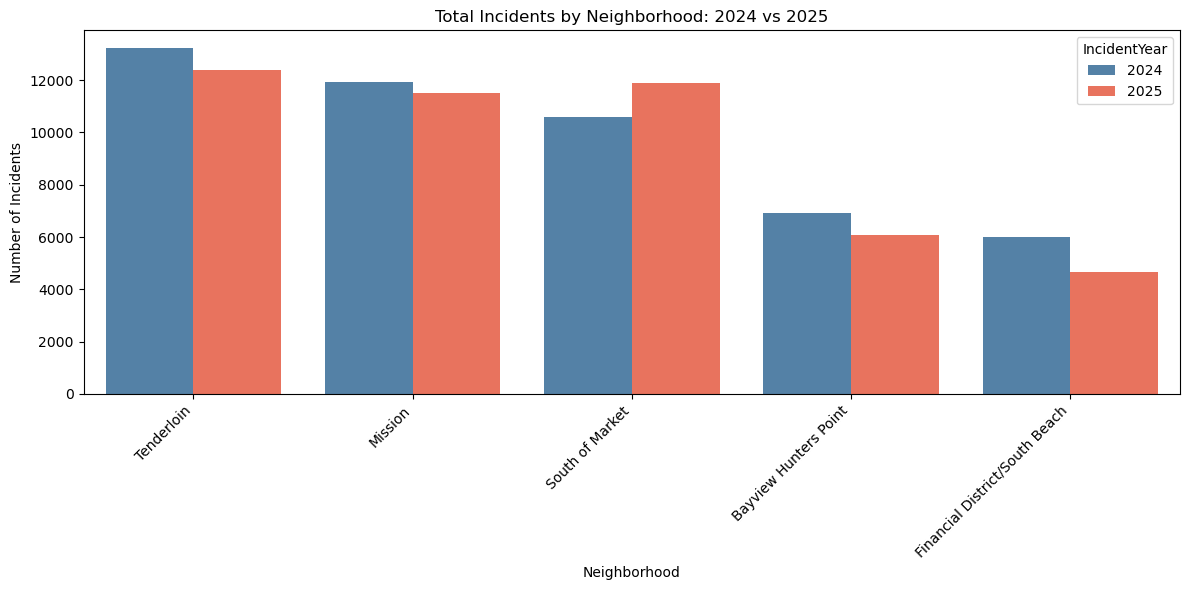

In [34]:
query1 = '''

WITH sub1 AS (
    SELECT 
        AnalysisNeighborhood, 
        IncidentYear,
        COUNT(IncidentCategory) AS num_incidents
    FROM sfcrime2025
    WHERE TRIM(AnalysisNeighborhood) <> ''
    GROUP BY AnalysisNeighborhood, IncidentYear

    UNION ALL

    SELECT 
        AnalysisNeighborhood, 
        IncidentYear,
        COUNT(IncidentCategory) AS num_incidents
    FROM sfcrime2024
    WHERE TRIM(AnalysisNeighborhood) <> ''
    GROUP BY AnalysisNeighborhood, IncidentYear

    ORDER BY AnalysisNeighborhood, IncidentYear
)
SELECT *
FROM sub1
ORDER BY num_incidents DESC
LIMIT 10;
'''

df1 = pd.read_sql(query1, engine)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df1, 
    x='AnalysisNeighborhood', 
    y='num_incidents',
    hue='IncidentYear', 
    palette={2024: 'steelblue', 2025: 'tomato'},  # custom colors per year
    ax=ax
)

ax.set_title('Total Incidents by Neighborhood: 2024 vs 2025')
ax.set_xlabel('Neighborhood')
ax.set_ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')  # 45 is more readable than 15
plt.tight_layout()
plt.show()


## 4(b). Most common crimes by neighborhood, 2024 vs 2025

Sicne this query is three dimensional, I will use a Heatmap in order to handle 
this level of complexity.
The heatmap will plot top crimes vs neighborhoods for a single year

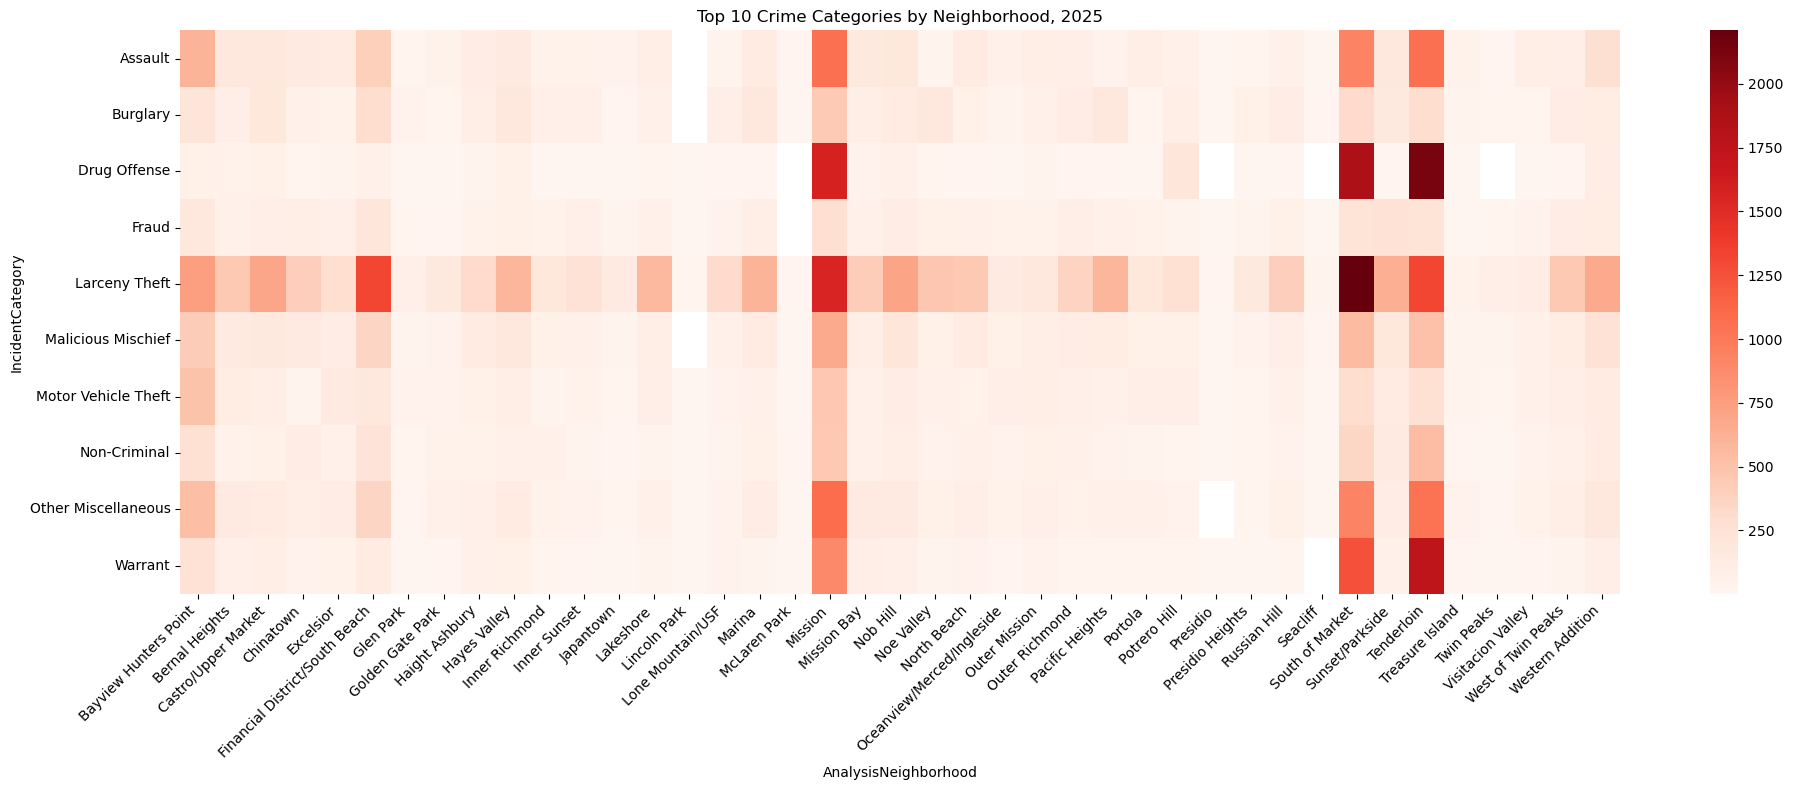

In [35]:
query2 = '''
SELECT
    IncidentCategory,
    AnalysisNeighborhood, 
    IncidentYear,
    COUNT(*) AS num_incidents
FROM sfcrime2025
WHERE TRIM(AnalysisNeighborhood) <> ''
  AND TRIM(IncidentCategory)     <> ''
GROUP BY IncidentCategory, AnalysisNeighborhood, IncidentYear

UNION ALL

SELECT 
    IncidentCategory,
    AnalysisNeighborhood, 
    IncidentYear,
    COUNT(*) AS num_incidents
FROM sfcrime2024
WHERE TRIM(AnalysisNeighborhood) <> ''
  AND TRIM(IncidentCategory)     <> ''
GROUP BY IncidentCategory, AnalysisNeighborhood, IncidentYear

ORDER BY IncidentCategory, AnalysisNeighborhood, num_incidents DESC;
'''
df2 = pd.read_sql(query2, engine)

top_categories = (df2[df2['IncidentYear'] == 2025]
                  .groupby('IncidentCategory')['num_incidents']
                  .sum()
                  .nlargest(10)
                  .index
                  )

df_filtered = df2[(df2['IncidentYear'] == 2025) &
                (df2['IncidentCategory'].isin(top_categories))]

pivot = df_filtered.pivot_table(
    values='num_incidents',
    index='IncidentCategory',
    columns='AnalysisNeighborhood'
)

fig, ax = plt.subplots(figsize=(20, 8))
sns.heatmap(
    pivot,
    cmap='Reds',        # darker = more incidents
    annot=False,        # too many cells for numbers
    ax=ax
)
ax.set_title('Top 10 Crime Categories by Neighborhood, 2025')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



# 4(c). How does resolution rate vary by neighborhood, 2024 vs 2025?

Resolution rate = % of incidents that resulted in 'Cite or Arrest Adult'

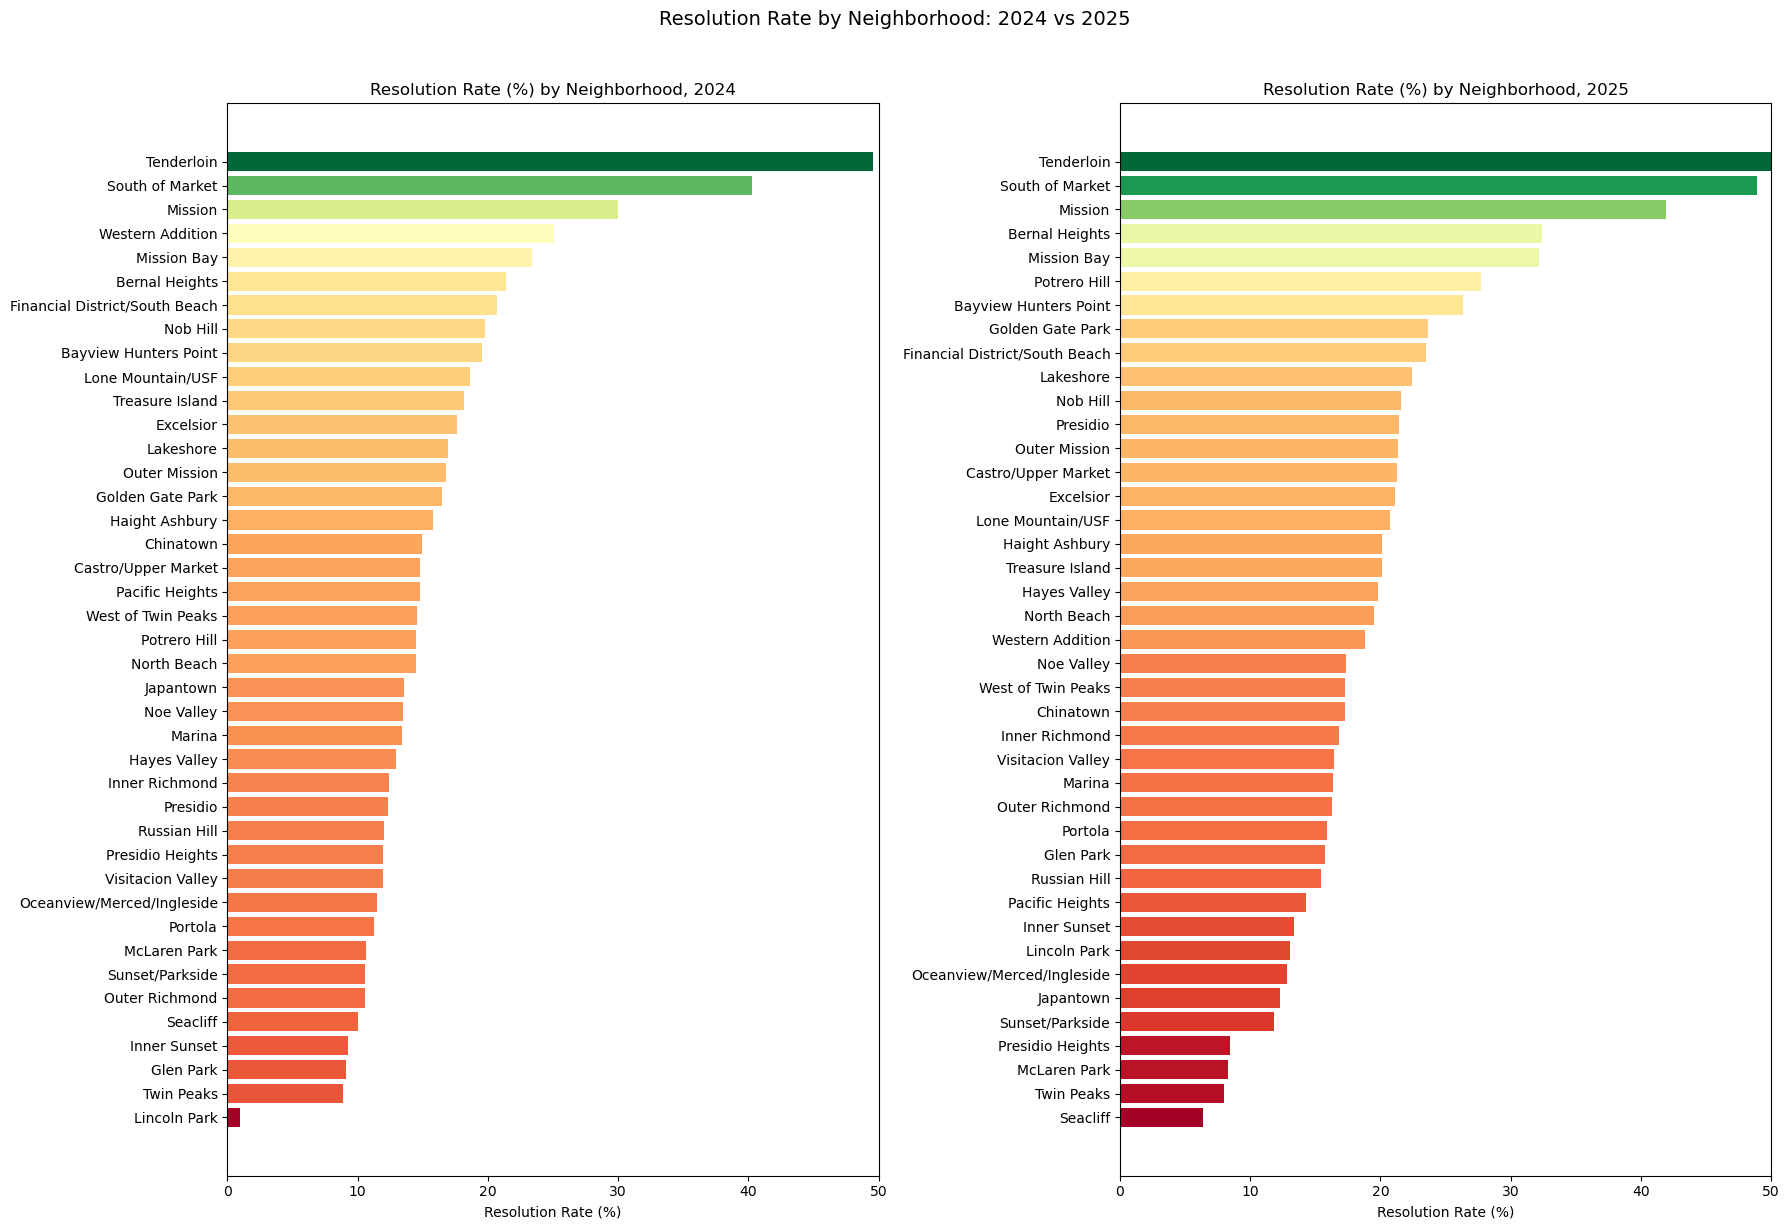

In [36]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
query3 = '''
SELECT
    AnalysisNeighborhood,
    IncidentYear,
    COUNT(*)                                                        AS total_incidents,
    SUM(CASE WHEN Resolution = 'Cite or Arrest Adult' THEN 1 
             ELSE 0 END)                                            AS total_resolved,
    ROUND(SUM(CASE WHEN Resolution = 'Cite or Arrest Adult' THEN 1 
                   ELSE 0 END) * 100.0 / COUNT(*), 2)              AS resolution_rate_pct
FROM sfcrime2025
WHERE TRIM(AnalysisNeighborhood) <> ''
GROUP BY AnalysisNeighborhood, IncidentYear

UNION ALL

SELECT
    AnalysisNeighborhood,
    IncidentYear,
    COUNT(*)                                                        AS total_incidents,
    SUM(CASE WHEN Resolution = 'Cite or Arrest Adult' THEN 1 
             ELSE 0 END)                                            AS total_resolved,
    ROUND(SUM(CASE WHEN Resolution = 'Cite or Arrest Adult' THEN 1 
                   ELSE 0 END) * 100.0 / COUNT(*), 2)              AS resolution_rate_pct
FROM sfcrime2024
WHERE TRIM(AnalysisNeighborhood) <> ''
GROUP BY AnalysisNeighborhood, IncidentYear

ORDER BY AnalysisNeighborhood, IncidentYear;
''' 

df3 = pd.read_sql(query3, engine)

def plot_resolution(df_year, ax, year):
    df_sorted = df_year.sort_values('resolution_rate_pct')
    
    # normalize values between 0 and 1 for colormap
    norm = mcolors.Normalize(vmin=df_sorted['resolution_rate_pct'].min(), 
                             vmax=df_sorted['resolution_rate_pct'].max())
    colors = cm.RdYlGn(norm(df_sorted['resolution_rate_pct']))  # color based on value
    
    ax.barh(df_sorted['AnalysisNeighborhood'], 
            df_sorted['resolution_rate_pct'], 
            color=colors)
    ax.set_title(f'Resolution Rate (%) by Neighborhood, {year}')
    ax.set_xlabel('Resolution Rate (%)')
    ax.set_xlim(0, 50)

fig, axes = plt.subplots(1, 2, figsize=(18, 12))

plot_resolution(df3[df3['IncidentYear'] == 2024], axes[0], 2024)
plot_resolution(df3[df3['IncidentYear'] == 2025], axes[1], 2025)

plt.suptitle('Resolution Rate by Neighborhood: 2024 vs 2025', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

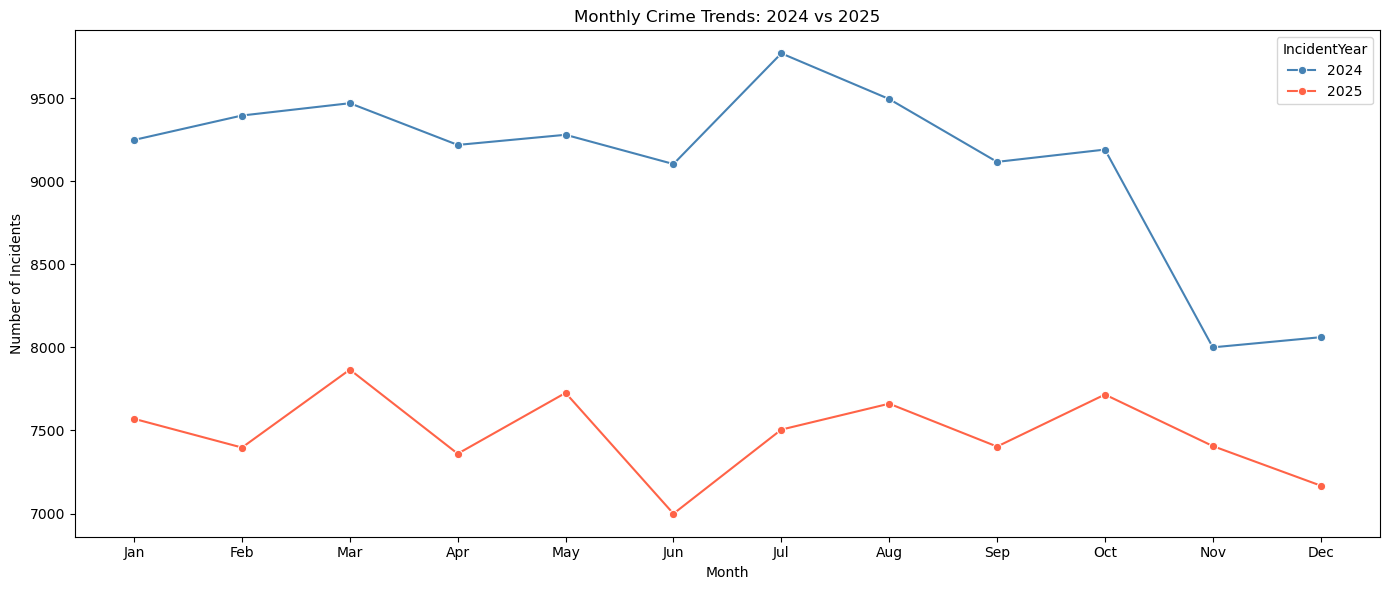

In [38]:
#  5(b). Do incidents follow a seasonal pattern across months?

query4 = '''
SELECT
    MONTH(IncidentDate)     AS incident_month,
    MONTHNAME(IncidentDate) AS month_name,
    IncidentYear,
    COUNT(*)                AS num_incidents
FROM sfcrime2025
WHERE TRIM(IncidentCategory) <> ''
GROUP BY incident_month, month_name, IncidentYear

UNION ALL

SELECT
    MONTH(IncidentDate)     AS incident_month,
    MONTHNAME(IncidentDate) AS month_name,
    IncidentYear,
    COUNT(*)                AS num_incidents
FROM sfcrime2024
WHERE TRIM(IncidentCategory) <> ''
GROUP BY incident_month, month_name, IncidentYear

ORDER BY IncidentYear, incident_month;
'''
df4 = pd.read_sql(query4, engine)

fig, ax = plt.subplots(figsize=(14, 6))

df4_filtered = df4[df4['IncidentYear'].isin([2024, 2025])]

sns.lineplot(
    data=df4_filtered,
    x='incident_month',
    y='num_incidents',
    hue='IncidentYear',
    palette={2024: 'steelblue', 2025: 'tomato'},
    marker='o',
    ax=ax
)

ax.set_title('Monthly Crime Trends: 2024 vs 2025')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Incidents')

# replace month numbers (1-12) with month names on x-axis
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.show()